# FineWeb-Edu GPT

Pretraining a decoder-only Transformer (grouped-query attention + RoPE + QK-norm) on [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) `sample-10BT`, tokenized with the pretrained [LiquidAI/LFM2.5-230M](https://huggingface.co/LiquidAI/LFM2.5-230M) subword tokenizer.

Unlike text8 (one continuous stream), FineWeb-Edu is many independent web documents, so the datamodule appends an end-of-document token (`<|endoftext|>`) after each one. The optimizer is **Muon for the hidden weight matrices + AdamW for the embeddings / head / norms**.

In [2]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina', 'svg']
%load_ext autoreload
%autoreload 2

import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from lightning import Trainer, seed_everything
from torchinfo import summary

from chimera.data import FineWebEduDataModule
from chimera.models import GPT
from chimera.modules import LanguageModelModule
from chimera.optim import LinearWarmupCosineAnnealingLR, Muon, muon_param_groups

# datasets + tokenizer caches live on the big volume
os.environ["HF_HOME"] = "/mnt/ai/data/hf"
os.environ["DATA_DIR"] = "/mnt/ai/data"

# Reproducibility: seed all RNGs (incl. dataloader workers). Pair with
# Trainer(deterministic=True) below for deterministic CUDA kernels too.
SEED = 42
seed_everything(SEED, workers=True)

SEQ_LEN = 2048

Seed set to 42


## Data

Load FineWeb-Edu `sample-10BT` and tokenize it with the fixed **LiquidAI/LFM2.5-230M** subword tokenizer (vocab ≈ 64k). Documents are concatenated with `<|endoftext|>` appended after each, so the model learns document boundaries instead of attending across unrelated pages.

`max_train_tokens` caps how many tokens are materialised into memory — the full 10BT sample is ~10B tokens, far more than fits in RAM with this simple in-memory pipeline. Raise it (or move to an on-disk memmap) for a real run.

In [3]:
dm = FineWebEduDataModule(
    data_dir=os.environ["DATA_DIR"],
    name="sample-10BT",
    batch_size=32,
    seq_len=SEQ_LEN,
    tokenizer_backend="pretrained",  # LiquidAI/LFM2.5-230M
    add_eos=True,  # append <|endoftext|> after each document
    max_train_tokens=1_000_000_000,
    num_workers=4,
)
dm.prepare_data()
dm.setup("fit")

train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

print(f"tokenizer={dm.pretrained_id}  vocab_size={dm.vocab_size}")
print(f"eos_token={dm.eos_token!r}  eos_id={dm.eos_id}")
print(f"train chunks={len(dm.train_dataset):,}  val chunks={len(dm.val_dataset):,}")

tokenizer=LiquidAI/LFM2.5-230M  vocab_size=64402
eos_token='<|endoftext|>'  eos_id=2
train chunks=483,398  val chunks=4,882


sample: ' posted everything on YouTube.\nIn summary, the samples passed the test. The ball had kinetic energy of 8314 Joules and it pushed the sapphire with a force of 2,771,440 Newtons in order to break the sapphire disk. Impressive strength. We also wrote a White'
<|endoftext|> tokens in one batch of 65,536: 54


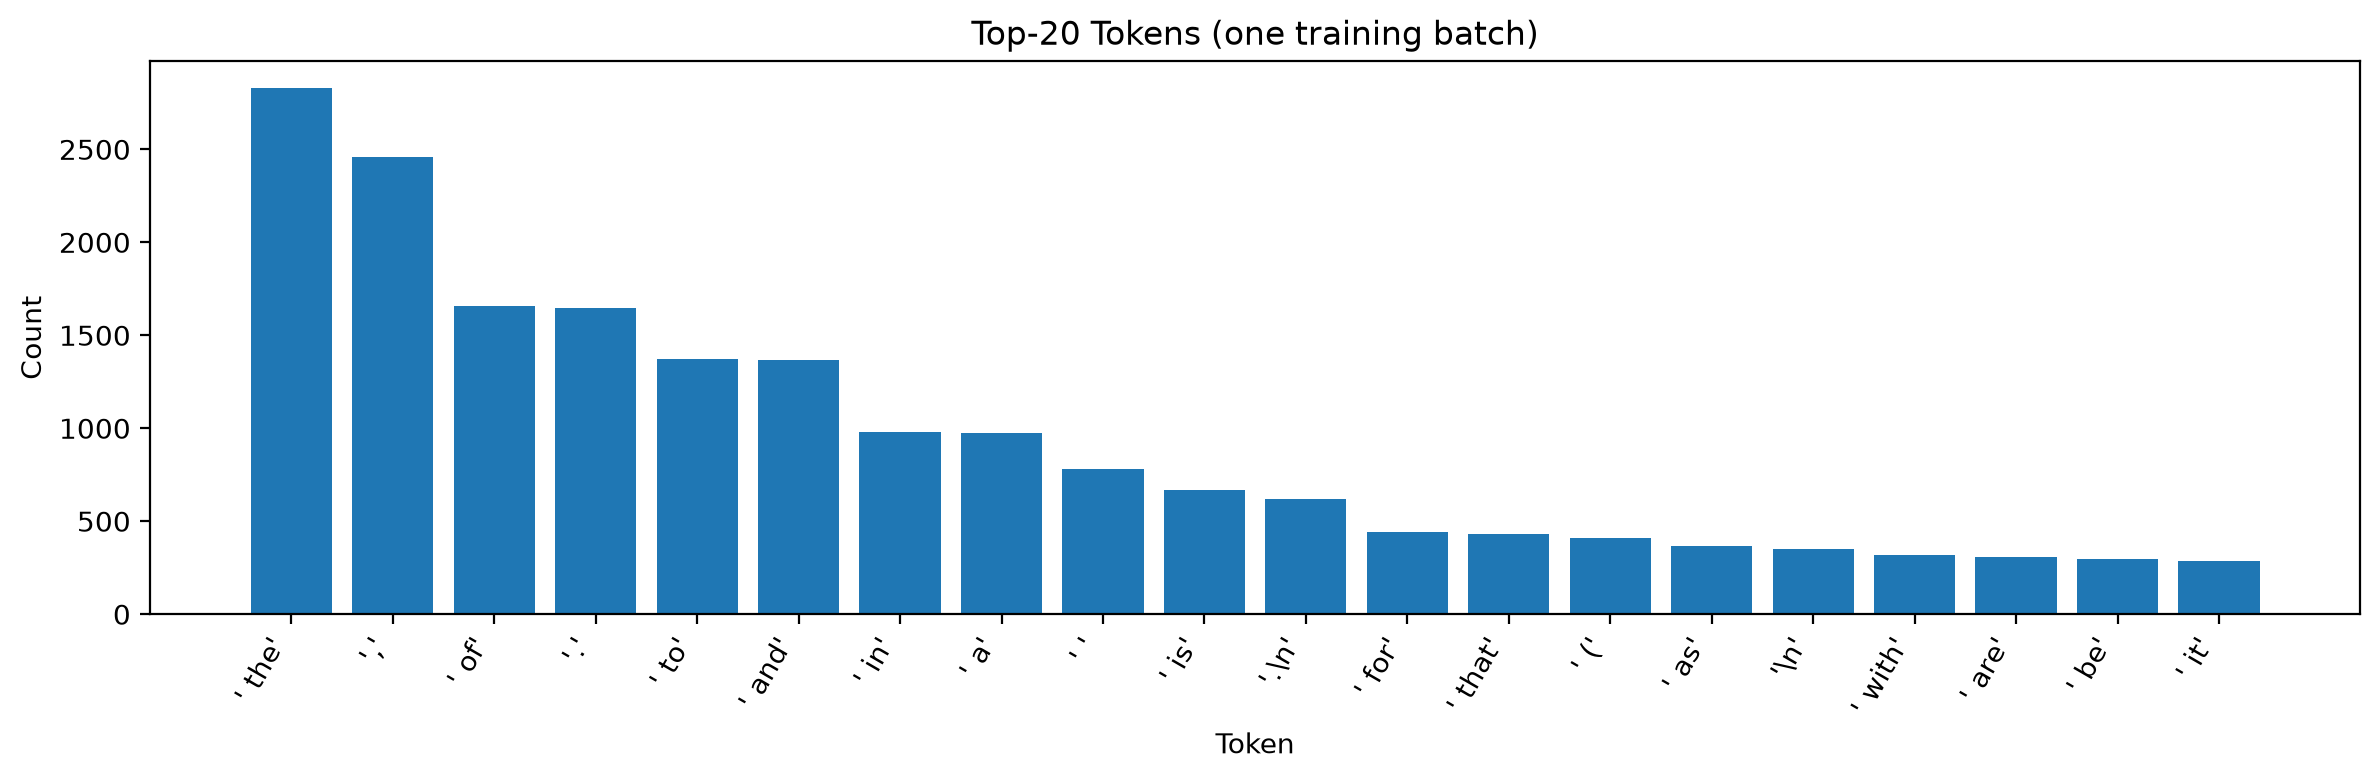

In [4]:
x, y = next(iter(train_loader))
print("sample:", repr(dm.decode(x[0][:64])))

# confirm the document separator is actually present in the stream
n_eos = int((x == dm.eos_id).sum())
print(f"<|endoftext|> tokens in one batch of {x.numel():,}: {n_eos}")

# most frequent tokens in one batch, shown as their decoded text
counts = Counter(x.flatten().tolist())
top = counts.most_common(20)
labels = [repr(dm.decode([tid])) for tid, _ in top]
values = [c for _, c in top]

plt.figure(figsize=(12, 4))
plt.bar(range(len(top)), values)
plt.title("Top-20 Tokens (one training batch)")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(range(len(top)), labels, rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Model

A decoder-only Transformer with grouped-query attention, rotary position embeddings, and QK-norm. `block_size` must match the datamodule's `seq_len`.

In [7]:
model = GPT(
    vocab_size=dm.vocab_size,
    block_size=SEQ_LEN,
    n_embd=384,
    n_head=12,
    n_kv_head=3,
    n_layer=6,
    tie_embedding=True,
)
summary(
    model,
    input_data=torch.zeros(1, SEQ_LEN, dtype=torch.long),
    col_names=["output_size", "num_params"],
    depth=1,
)

Layer (type:depth-idx)                        Output Shape              Param #
GPT                                           [1, 2048, 64402]          --
├─Embedding: 1-1                              [1, 2048, 384]            24,730,368
├─RotaryEmbedding: 1-2                        [2048, 32]                --
├─ModuleList: 1-3                             --                        9,308,544
├─RMSNorm: 1-4                                [1, 2048, 384]            384
Total params: 34,039,296
Trainable params: 34,039,296
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 34.04
Input size (MB): 0.02
Forward/backward pass size (MB): 418.38
Params size (MB): 136.16
Estimated Total Size (MB): 554.56

loss at init: 11.1362  (expect >= ln(vocab_size) = 11.0729)
tok_emb  mean=0.0000  std=0.0200

Output std by layer (rows = transformer block, darker = larger):


component,attn.q_proj,attn.kv_proj,attn.proj,mlp.fc1,mlp.fc2
block,,,,,
0,0.392,0.393,0.012,0.391,0.042
1,0.390,0.393,0.022,0.392,0.045
2,0.395,0.396,0.027,0.394,0.042
3,0.396,0.384,0.028,0.392,0.043
4,0.388,0.377,0.030,0.394,0.042
5,0.392,0.400,0.033,0.386,0.043


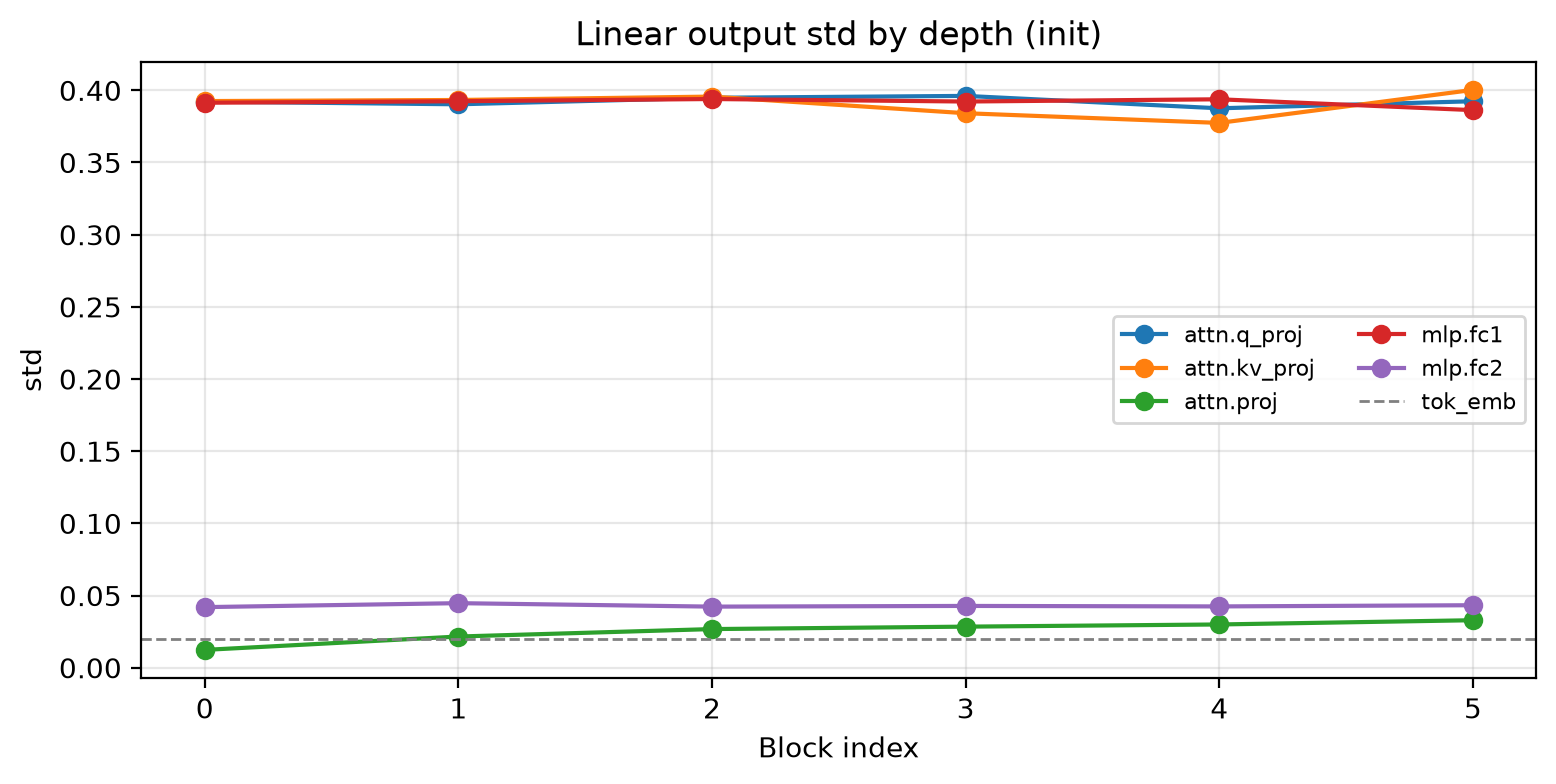

In [8]:
# Activation health check: per-layer output scale at initialization.
#
# Bugs fixed here:
#  - `logits, _ = model(x)` unpacked a tensor as if forward() returned a tuple
#    (it just returns logits), so it always raised before printing the loss.
#  - hooks were only removed on success, so every failed rerun left a stale
#    set attached to `model` — each new run added another, which is why every
#    line printed twice (or more, the more times it had failed before).
#  - the loss compared each position's logits against the token at that SAME
#    position, not the next one. Since position t's hidden state starts from
#    tok_emb(x[t]) and flows straight through the residual stream, the model
#    can "predict" x[t] from itself for free (a shortcut, not a real
#    prediction) — that's what made the old loss (~9.9) sit well below
#    ln(vocab_size), not anything wrong with the model. Scored on the real
#    next-token task the loss lands at ~ln(vocab_size), slightly above it
#    (cross-entropy against a random/uniform target is >= ln(V), not exactly
#    equal to it).
# It also forwarded a full training-sized batch (32 x SEQ_LEN) and materialized
# (B, T, vocab_size) logits just to read off mean/std, which is the real
# reason it took 1min+. A small batch on the GPU is enough for these stats.
import math

import pandas as pd

for h in globals().get("_ACTIVATION_HOOKS", []):
    h.remove()

CHECK_BATCH, CHECK_SEQ = 8, 128
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

records = []


def make_hook(name):
    def hook(module, inputs, output):
        if isinstance(output, tuple):
            output = output[0]
        records.append(
            {"layer": name, "mean": output.mean().item(), "std": output.std().item()}
        )

    return hook


_ACTIVATION_HOOKS = [
    module.register_forward_hook(make_hook(name))
    for name, module in model.named_modules()
    if isinstance(module, (torch.nn.Linear, torch.nn.Embedding))
]

try:
    with torch.no_grad():
        x = torch.randint(0, dm.vocab_size, (CHECK_BATCH, CHECK_SEQ), device=device)
        logits = model(x)
        # next-token prediction, same as training: logits at t predict x[t+1]
        loss = torch.nn.functional.cross_entropy(
            logits[:, :-1].reshape(-1, logits.size(-1)), x[:, 1:].reshape(-1)
        )
finally:
    for h in _ACTIVATION_HOOKS:
        h.remove()

print(
    f"loss at init: {loss.item():.4f}  (expect >= ln(vocab_size) = {math.log(dm.vocab_size):.4f})"
)

df = pd.DataFrame(records)
emb = df[df["layer"] == "tok_emb"].iloc[0]
blocks = df[df["layer"].str.startswith("blocks.")].copy()
blocks["block"] = blocks["layer"].str.extract(r"blocks\.(\d+)\.").astype(int)
blocks["component"] = blocks["layer"].str.extract(r"blocks\.\d+\.(.+)")

pivot = blocks.pivot(index="block", columns="component", values="std")
pivot = pivot[["attn.q_proj", "attn.kv_proj", "attn.proj", "mlp.fc1", "mlp.fc2"]]

print(f"tok_emb  mean={emb['mean']:.4f}  std={emb['std']:.4f}\n")
print("Output std by layer (rows = transformer block, darker = larger):")
display(pivot.style.format("{:.3f}").background_gradient(cmap="RdYlGn_r", axis=None))

fig, ax = plt.subplots(figsize=(9, 4))
for component in pivot.columns:
    ax.plot(pivot.index, pivot[component], marker="o", label=component)
ax.axhline(emb["std"], color="gray", ls="--", lw=1, label="tok_emb")
ax.set_title("Linear output std by depth (init)")
ax.set_xlabel("Block index")
ax.set_ylabel("std")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.show()

## Training

Optimize with **Muon + AdamW**: `muon_param_groups` routes the 2D hidden weight matrices (attention + MLP) to Muon and the token embedding, output head, biases, and norm gains to AdamW. Both groups share one `LinearWarmupCosineAnnealingLR` schedule (each anneals from its own base LR).

`N_EPOCH=1` over the capped token budget is a quick smoke run — raise the token cap and epochs for a real one.

In [ ]:
N_EPOCH = 1

optimizer = Muon(
    muon_param_groups(
        model,
        muon_lr=0.02,
        adamw_lr=8e-4,
        adamw_weight_decay=0.01,
    )
)
scheduler = LinearWarmupCosineAnnealingLR(
    optimizer,
    warmup_steps=100,
    n_epochs=N_EPOCH,
    train_loader=train_loader,
)

model = torch.compile(model, mode="reduce-overhead")
# use_cce: fuse lm_head + cross-entropy (apple/ml-cross-entropy), no logits materialized
lm_module = LanguageModelModule(model, optimizer, scheduler, use_cce=True)

trainer = Trainer(
    max_epochs=N_EPOCH,
    precision="bf16-true",
    gradient_clip_val=1.0,
    deterministic=True,
)

trainer.fit(lm_module, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(lm_module, dataloaders=val_loader)

## Analysis

Plot the logged loss and bits-per-token curves, then sample text from the trained model.

In [ ]:
metrics = np.genfromtxt(
    f"{trainer.logger.log_dir}/metrics.csv", delimiter=",", names=True
)


def series(step_key, value_key):
    step = metrics[step_key]
    value = metrics[value_key]
    mask = ~np.isnan(value)
    return step[mask], value[mask]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Training Metrics")

for ax, metric, title in zip(
    [axes[0], axes[1]], ["loss", "bpt"], ["Loss (nats)", "Bits per Token"]
):
    train_step, train_val = series("step", f"train{metric}")
    val_step, val_val = series("step", f"val{metric}")
    ax.plot(train_step, train_val, marker="o", label="train")
    ax.plot(val_step, val_val, marker="o", label="val")
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()

In [ ]:
# Lightning moves the model to CPU after trainer.test(), so put it back on the GPU —
# otherwise generation runs on CPU and is ~30x slower.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

prompt = "The role of education in modern society is "
idx = torch.tensor([dm.tokenizer.encode(prompt)], device=device)

# Eager by default (no compile warmup). Pass compile=True for ~2x faster decode
# when generating repeatedly — it costs a one-time ~10s compile on the first call.
generated = model.generate(idx, max_new_tokens=200, temperature=0.8)
print(dm.decode(generated[0].cpu()))